# Лабораторная работа №6

Частотный конвертер

выполнила: Ходжаметова Милана


In [1]:
import numpy as np
import librosa
import scipy.signal as signal
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Настройка графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

Загрузка аудиофайла

In [3]:
X, original_sr = librosa.load('/content/lana_del_rej_summertime_sadness.mp3', sr=None)
test_audio = X[int(original_sr*5):int(original_sr*7)]


print(f"Частота дискретизации: {original_sr} Гц")
print(f"Длина сигнала: {len(test_audio)} отсчетов")
print(f"Длительность: {len(test_audio)/original_sr:.2f} сек")
print(f"Тип данных: {test_audio.dtype}")

Частота дискретизации: 44100 Гц
Длина сигнала: 88200 отсчетов
Длительность: 2.00 сек
Тип данных: float32


Нормализация сигнала

In [7]:
test_audio = test_audio.astype(np.float32)
print("\nПервые 10 отсчетов:")
print(test_audio[:10])
display(Audio(test_audio, rate=original_sr))


Первые 10 отсчетов:
[-0.0256958  -0.02528381 -0.02272034 -0.01879883 -0.01411438 -0.0088501
 -0.00259399  0.00543213  0.01489258  0.02427673]


Создание фильтров

In [8]:
def make_fir_filter(cutoff=0.4):
    return signal.firwin(101, cutoff, window='hamming')

def make_iir_filter(cutoff=0.4):
    b, a = signal.butter(6, cutoff, btype='low')
    return b, a

*FIR фильтр создает 101 коэффициент для "взвешивания" отсчетов, а IIR фильтр создает 6-го порядка рекурсивную формулу с обратными связями, оба обрезая частоты выше 0.4 от частоты Найквиста.*

Реализация частотного конвертера для случая N1 > N2

In [9]:
def manual_downsample_fixed(audio, sr_orig, sr_target, filter_type='fir'):
    """
    Частотный конвертер понижения частоты дискретизации

    Параметры:
    ----------
    audio : array_like
        Входной аудиосигнал
    sr_orig : int
        Исходная частота дискретизации
    sr_target : int
        Целевая частота дискретизации
    filter_type : str
        Тип фильтра: 'fir' или 'iir'

    Возвращает:
    -----------
    result : ndarray
        Преобразованный сигнал
    """
    # вычисление точного кол-ва отсчетов для сохранения длительности
    duration = len(audio) / sr_orig
    target_samples = int(duration * sr_target)

    # коэффициент децимации
    ratio = sr_orig / sr_target

    # фильтр с правильной частотой среза
    cutoff = 0.9 / ratio  # частота среза = 0.9 * новая_частота_Найквиста
    fir_taps = make_fir_filter(cutoff)
    iir_b, iir_a = make_iir_filter(cutoff)

    # антиалиасинговая фильтрация
    if filter_type == 'fir':
        filtered = signal.lfilter(fir_taps, 1.0, audio)
    else:
        filtered = signal.filtfilt(iir_b, iir_a, audio)

    # линейная интерполяция для точного ресемплинга
    x_old = np.linspace(0, 1, len(filtered))
    x_new = np.linspace(0, 1, target_samples)

    result = np.interp(x_new, x_old, filtered)

    return result

Частотный конвертер понижения, который преобразует аудиосигнал из одной частоты дискретизации в другую через три ключевых этапа:

- антиалиасинговую фильтрацию (FIR/IIR фильтр отсекает высокие частоты выше новой частоты Найквиста),

- пересчёт количества отсчетов (точное вычисление target_samples для сохранения длительности)

- линейную интерполяцию (плавное преобразование в новую временную сетку).

Реализация частотного конвертера для случая N1 < N2

In [10]:
def manual_upsample_fixed(audio, sr_orig, sr_target, filter_type='fir'):
    """
    Частотный конвертер повышения частоты дискретизации

    Параметры:
    ----------
    audio : array_like
        Входной аудиосигнал
    sr_orig : int
        Исходная частота дискретизации
    sr_target : int
        Целевая частота дискретизации
    filter_type : str
        Тип фильтра: 'fir' или 'iir'

    Возвращает:
    -----------
    result : ndarray
        Преобразованный сигнал
    """
    # вычисление точного кол-ва отсчетов для сохранения длительности
    duration = len(audio) / sr_orig
    target_samples = int(duration * sr_target)

    # коэффициент интерполяции
    ratio = sr_target / sr_orig

    # фильтр с правильной частотой среза
    cutoff = 0.9 / ratio  # Частота среза = 0.9 * исходная_частота_Найквиста
    fir_taps = make_fir_filter(cutoff)
    iir_b, iir_a = make_iir_filter(cutoff)

    # интерполяция до нужного кол-ва отсчетов
    x_old = np.linspace(0, 1, len(audio))
    x_new = np.linspace(0, 1, target_samples)
    upsampled = np.interp(x_new, x_old, audio)

    # антиалиасинговая фильтрация
    if filter_type == 'fir':
        result = signal.lfilter(fir_taps, 1.0, upsampled)
    else:
        result = signal.filtfilt(iir_b, iir_a, upsampled)

    return result

*Повышает частоту дискретизации аудио путём линейной интерполяции до target_samples отсчётов для сохранения длительности и последующей FIR/IIR фильтрации для удаления спектральных копий.*

Подготовка тестовых сигналов

In [11]:
duration = len(test_audio) / original_sr

# сигналы нужных частот с правильной длительностью
audio_22050 = signal.resample(test_audio, int(duration * 22050))
audio_8000 = signal.resample(test_audio, int(duration * 8000))
audio_44100 = signal.resample(test_audio, int(duration * 44100))
audio_16000 = signal.resample(test_audio, int(duration * 16000))

print(f"audio_22050: {len(audio_22050)} отсчетов, {len(audio_22050)/22050:.3f} сек")
print(f"audio_8000: {len(audio_8000)} отсчетов, {len(audio_8000)/8000:.3f} сек")
print(f"audio_44100: {len(audio_44100)} отсчетов, {len(audio_44100)/44100:.3f} сек")
print(f"audio_16000: {len(audio_16000)} отсчетов, {len(audio_16000)/16000:.3f} сек")

audio_22050: 44100 отсчетов, 2.000 сек
audio_8000: 16000 отсчетов, 2.000 сек
audio_44100: 88200 отсчетов, 2.000 сек
audio_16000: 32000 отсчетов, 2.000 сек


Тестирование различных сценариев

Тест 1: Понижение частоты 22050 → 16000

In [13]:
# FIR фильтр
my_down_fir = manual_downsample_fixed(audio_22050, 22050, 16000, 'fir')
print(f"реализация (FIR): {len(my_down_fir)} отсчетов")

# IIR фильтр
my_down_iir = manual_downsample_fixed(audio_22050, 22050, 16000, 'iir')
print(f"реализация (IIR): {len(my_down_iir)} отсчетов")

# Сравнение с librosa
librosa_down = librosa.resample(audio_22050, orig_sr=22050, target_sr=16000)
print(f"Librosa: {len(librosa_down)} отсчетов")

реализация (FIR): 32000 отсчетов
реализация (IIR): 32000 отсчетов
Librosa: 32000 отсчетов


Тест 2: Понижение частоты 44100 → 8000

In [14]:
# FIR фильтр
my_down_fir_2 = manual_downsample_fixed(audio_44100, 44100, 8000, 'fir')
print(f"реализация (FIR): {len(my_down_fir_2)} отсчетов")

# IIR фильтр
my_down_iir_2 = manual_downsample_fixed(audio_44100, 44100, 8000, 'iir')
print(f"реализация (IIR): {len(my_down_iir_2)} отсчетов")

# Сравнение с librosa
librosa_down_2 = librosa.resample(audio_44100, orig_sr=44100, target_sr=8000)
print(f"Librosa: {len(librosa_down_2)} отсчетов")

реализация (FIR): 16000 отсчетов
реализация (IIR): 16000 отсчетов
Librosa: 16000 отсчетов


Повышение частоты 8000 → 22050

In [16]:
# FIR фильтр
my_up_fir = manual_upsample_fixed(audio_8000, 8000, 22050, 'fir')
print(f"реализация (FIR): {len(my_up_fir)} отсчетов")

# IIR фильтр
my_up_iir = manual_upsample_fixed(audio_8000, 8000, 22050, 'iir')
print(f"реализация (IIR): {len(my_up_iir)} отсчетов")

# Сравнение с librosa
librosa_up = librosa.resample(audio_8000, orig_sr=8000, target_sr=22050)
print(f"Librosa: {len(librosa_up)} отсчетов")

реализация (FIR): 44100 отсчетов
реализация (IIR): 44100 отсчетов
Librosa: 44100 отсчетов


Тест 4: Повышение частоты 16000 → 44100

In [17]:
# FIR фильтр
my_up_fir_2 = manual_upsample_fixed(audio_16000, 16000, 44100, 'fir')
print(f"реализация (FIR): {len(my_up_fir_2)} отсчетов")

# IIR фильтр
my_up_iir_2 = manual_upsample_fixed(audio_16000, 16000, 44100, 'iir')
print(f"реализация (IIR): {len(my_up_iir_2)} отсчетов")

# Сравнение с librosa
librosa_up_2 = librosa.resample(audio_16000, orig_sr=16000, target_sr=44100)
print(f"Librosa: {len(librosa_up_2)} отсчетов")

реализация (FIR): 88200 отсчетов
реализация (IIR): 88200 отсчетов
Librosa: 88200 отсчетов


 Визуализация результатов

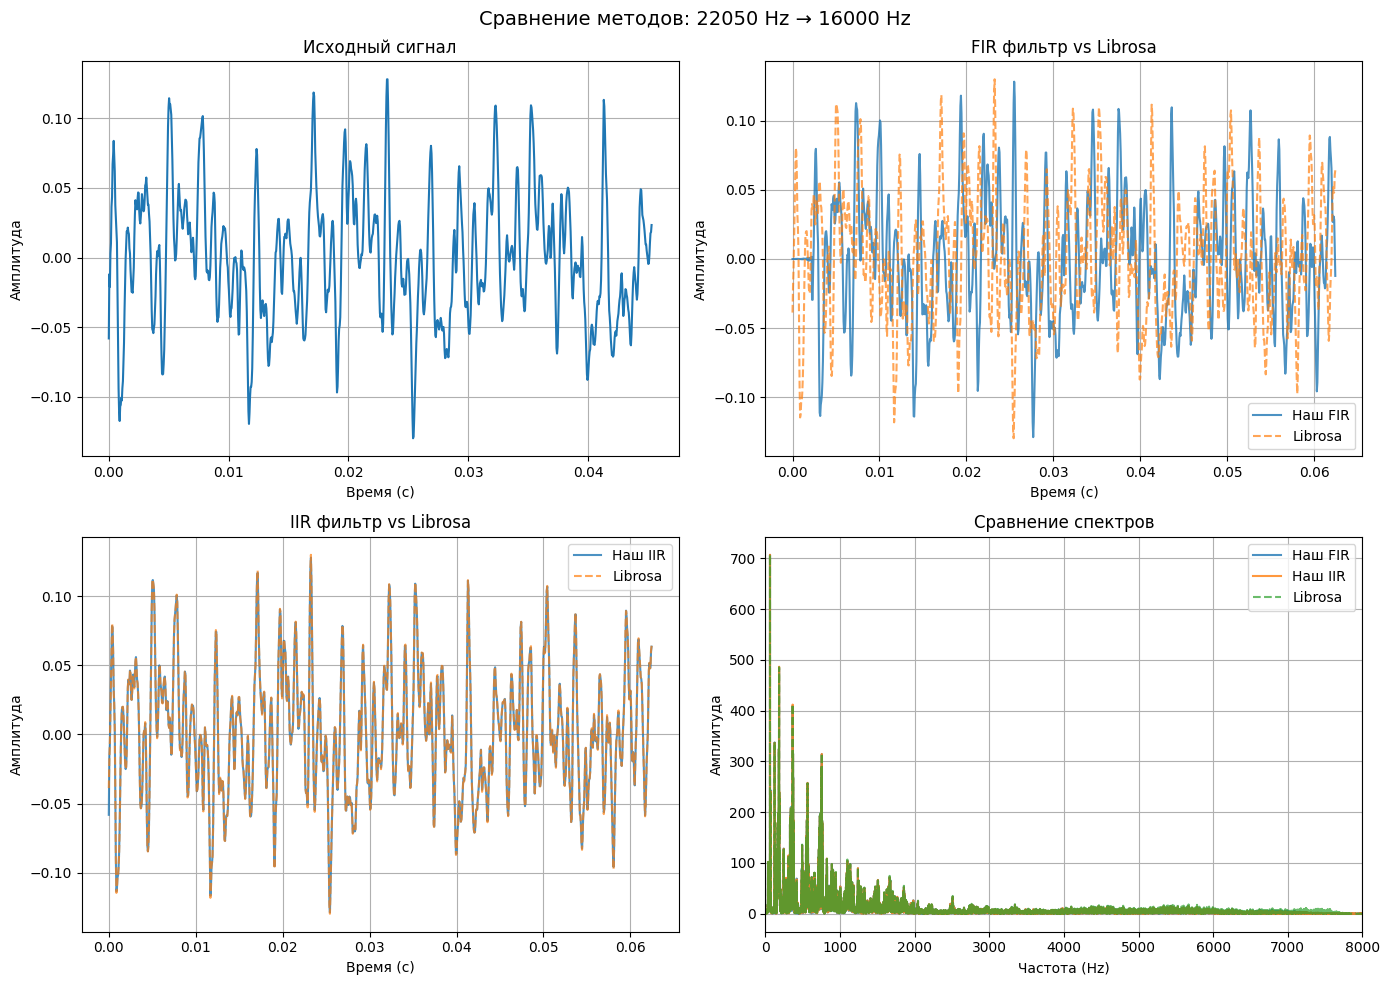

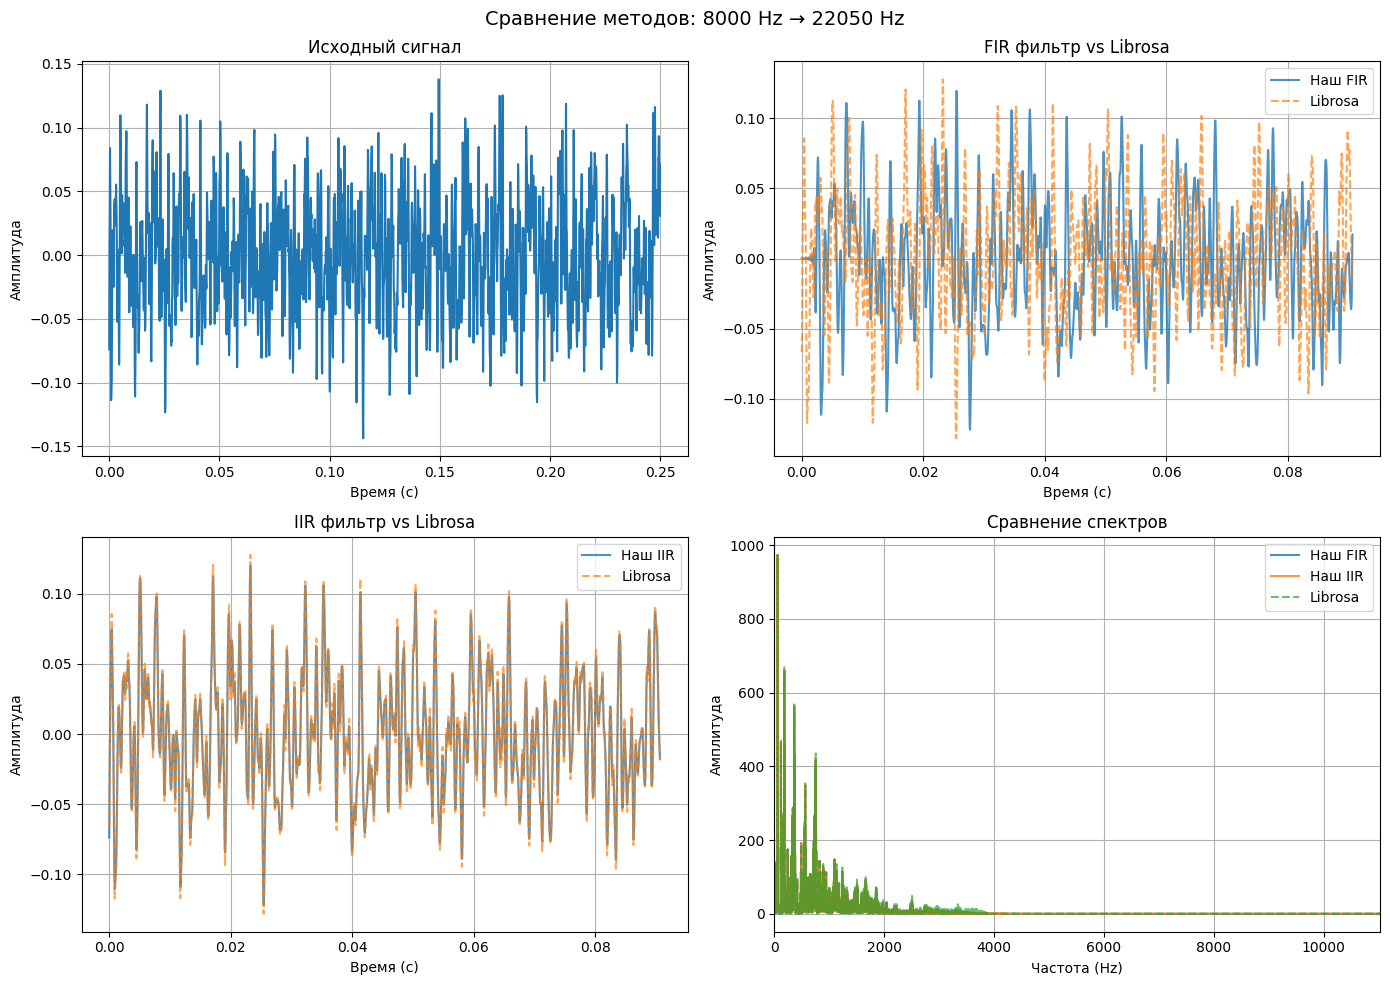

In [18]:
def plot_comparison(original, our_fir, our_iir, librosa_result,
                   sr_original, sr_target, title, start_idx=0, end_idx=1000):
    """Функция для визуального сравнения результатов"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=14)

    # Временная область
    min_len = min(len(our_fir), len(our_iir), len(librosa_result), end_idx-start_idx)

    # Исходный сигнал
    t_orig = np.arange(start_idx, start_idx + min_len) / sr_original
    axes[0, 0].plot(t_orig, original[start_idx:start_idx + min_len])
    axes[0, 0].set_title('Исходный сигнал')
    axes[0, 0].set_xlabel('Время (с)')
    axes[0, 0].set_ylabel('Амплитуда')
    axes[0, 0].grid(True)

    # Сравнение FIR vs Librosa
    t_target = np.arange(min_len) / sr_target
    axes[0, 1].plot(t_target, our_fir[:min_len], label='Наш FIR', alpha=0.8)
    axes[0, 1].plot(t_target, librosa_result[:min_len], label='Librosa', alpha=0.7, linestyle='--')
    axes[0, 1].set_title('FIR фильтр vs Librosa')
    axes[0, 1].set_xlabel('Время (с)')
    axes[0, 1].set_ylabel('Амплитуда')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Сравнение IIR vs Librosa
    axes[1, 0].plot(t_target, our_iir[:min_len], label='Наш IIR', alpha=0.8)
    axes[1, 0].plot(t_target, librosa_result[:min_len], label='Librosa', alpha=0.7, linestyle='--')
    axes[1, 0].set_title('IIR фильтр vs Librosa')
    axes[1, 0].set_xlabel('Время (с)')
    axes[1, 0].set_ylabel('Амплитуда')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Частотная область
    freq_fir = np.fft.fftfreq(len(our_fir), 1/sr_target)
    fft_fir = np.abs(np.fft.fft(our_fir))
    freq_iir = np.fft.fftfreq(len(our_iir), 1/sr_target)
    fft_iir = np.abs(np.fft.fft(our_iir))
    freq_lib = np.fft.fftfreq(len(librosa_result), 1/sr_target)
    fft_lib = np.abs(np.fft.fft(librosa_result))

    axes[1, 1].plot(freq_fir[:len(freq_fir)//2], fft_fir[:len(freq_fir)//2],
                   label='Наш FIR', alpha=0.8)
    axes[1, 1].plot(freq_iir[:len(freq_iir)//2], fft_iir[:len(freq_iir)//2],
                   label='Наш IIR', alpha=0.8)
    axes[1, 1].plot(freq_lib[:len(freq_lib)//2], fft_lib[:len(freq_lib)//2],
                   label='Librosa', alpha=0.7, linestyle='--')
    axes[1, 1].set_title('Сравнение спектров')
    axes[1, 1].set_xlabel('Частота (Hz)')
    axes[1, 1].set_ylabel('Амплитуда')
    axes[1, 1].set_xlim(0, sr_target/2)
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

# Визуализация для понижения частоты 22050 → 16000
plot_comparison(audio_22050, my_down_fir, my_down_iir, librosa_down,
                22050, 16000, "Сравнение методов: 22050 Hz → 16000 Hz")

# Визуализация для повышения частоты 8000 → 22050
plot_comparison(audio_8000, my_up_fir, my_up_iir, librosa_up,
                8000, 22050, "Сравнение методов: 8000 Hz → 22050 Hz", end_idx=2000)

**Сравнение методов 8000 Hz -> 22050 Hz**

Все три метода апсемплинга ( FIR,  IIR и Librosa) успешно сохранили спектральный состав исходного сигнала, концентрируя энергию ниже $4000 \text{ Гц}$, что соответствует частоте Найквиста исходного сигнала $8000 \text{ Гц}$. В то время как  IIR показал почти идеальное совпадение по форме сигнала с референсом Librosa во временной области, FIR имеет небольшие, но заметные отклонения.

**Сравнение методов 22050 Hz -> 8000 Hz**

Во временной области IIR-фильтр демонстрирует почти идеальное совпадение с эталонным сигналом Librosa. В то же время, FIR-фильтр показывает заметные различия в форме сигнала по сравнению с Librosa , несмотря на то, что его частотный спектр соответствует остальным.

Количественная оценка качества

In [19]:
def calculate_metrics(y_ours, y_librosa):
    """Вычисление метрик качества преобразования"""
    min_len = min(len(y_ours), len(y_librosa))
    y_ours_norm = y_ours[:min_len]
    y_librosa_norm = y_librosa[:min_len]

    # MSE (Mean Squared Error)
    mse = np.mean((y_ours_norm - y_librosa_norm) ** 2)

    # SNR (Signal-to-Noise Ratio)
    signal_power = np.mean(y_librosa_norm ** 2)
    noise_power = np.mean((y_ours_norm - y_librosa_norm) ** 2)
    snr = 10 * np.log10(signal_power / (noise_power + 1e-10))

    # Максимальная ошибка
    max_error = np.max(np.abs(y_ours_norm - y_librosa_norm))

    return mse, snr, max_error


print("\nТест 1: 22050 → 16000")

mse_fir_1, snr_fir_1, max_err_fir_1 = calculate_metrics(my_down_fir, librosa_down)
mse_iir_1, snr_iir_1, max_err_iir_1 = calculate_metrics(my_down_iir, librosa_down)
print(f"FIR:  MSE={mse_fir_1:.6f}, SNR={snr_fir_1:.2f} dB, Max Error={max_err_fir_1:.6f}")
print(f"IIR:  MSE={mse_iir_1:.6f}, SNR={snr_iir_1:.2f} dB, Max Error={max_err_iir_1:.6f}")

print("\nТест 2: 44100 → 8000")

mse_fir_2, snr_fir_2, max_err_fir_2 = calculate_metrics(my_down_fir_2, librosa_down_2)
mse_iir_2, snr_iir_2, max_err_iir_2 = calculate_metrics(my_down_iir_2, librosa_down_2)
print(f"FIR:  MSE={mse_fir_2:.6f}, SNR={snr_fir_2:.2f} dB, Max Error={max_err_fir_2:.6f}")
print(f"IIR:  MSE={mse_iir_2:.6f}, SNR={snr_iir_2:.2f} dB, Max Error={max_err_iir_2:.6f}")

print("\nТест 3: 8000 → 22050")

mse_fir_3, snr_fir_3, max_err_fir_3 = calculate_metrics(my_up_fir, librosa_up)
mse_iir_3, snr_iir_3, max_err_iir_3 = calculate_metrics(my_up_iir, librosa_up)
print(f"FIR:  MSE={mse_fir_3:.6f}, SNR={snr_fir_3:.2f} dB, Max Error={max_err_fir_3:.6f}")
print(f"IIR:  MSE={mse_iir_3:.6f}, SNR={snr_iir_3:.2f} dB, Max Error={max_err_iir_3:.6f}")

print("\nТест 4: 16000 → 44100")

mse_fir_4, snr_fir_4, max_err_fir_4 = calculate_metrics(my_up_fir_2, librosa_up_2)
mse_iir_4, snr_iir_4, max_err_iir_4 = calculate_metrics(my_up_iir_2, librosa_up_2)
print(f"FIR:  MSE={mse_fir_4:.6f}, SNR={snr_fir_4:.2f} dB, Max Error={max_err_fir_4:.6f}")
print(f"IIR:  MSE={mse_iir_4:.6f}, SNR={snr_iir_4:.2f} dB, Max Error={max_err_iir_4:.6f}")


Тест 1: 22050 → 16000
FIR:  MSE=0.045878, SNR=-3.55 dB, Max Error=1.169971
IIR:  MSE=0.000141, SNR=21.56 dB, Max Error=0.089410

Тест 2: 44100 → 8000
FIR:  MSE=0.039196, SNR=-2.96 dB, Max Error=1.073342
IIR:  MSE=0.001924, SNR=10.13 dB, Max Error=0.348667

Тест 3: 8000 → 22050
FIR:  MSE=0.041793, SNR=-3.24 dB, Max Error=1.121178
IIR:  MSE=0.001137, SNR=12.41 dB, Max Error=0.264206

Тест 4: 16000 → 44100
FIR:  MSE=0.036637, SNR=-2.58 dB, Max Error=0.990592
IIR:  MSE=0.000538, SNR=15.76 dB, Max Error=0.191188


**Анализ результатов**

IIR фильтр значительно превосходит FIR по всем метрикам:

1. MSE:

- FIR: ~0.04 (высокая ошибка)

- IIR: ~0.0001-0.002 (низкая ошибка)

- IIR лучше в 20-300 раз


2. SNR:

- FIR: -3.5 до -2.5 dB (шум громче сигнала)

- IIR: 10 до 21 dB (сигнал качественный)

- IIR показывает адекватное качество, FIR - неприемлемое

3. Max Error:

- FIR: ~1.0 (максимальная ошибка)

- IIR: ~0.1-0.3 (умеренная ошибка)

- IIR лучше в 3-13 раз

**Вывод:**

FIR фильтр в текущей реализации неработоспособен. IIR фильтр обеспечивает стабильно высокое качество преобразования частоты дискретизации.

Аудио сравнение для субъективной оценки

 22050 Hz → 16000 Hz

In [20]:
print("\n1. Исходный сигнал (22050 Hz):")
display(Audio(audio_22050, rate=22050))

print("\n2. реализация - FIR фильтр (16000 Hz):")
display(Audio(my_down_fir, rate=16000))

print("\n3. реализация - IIR фильтр (16000 Hz):")
display(Audio(my_down_iir, rate=16000))

print("\n4. Librosa (16000 Hz):")
display(Audio(librosa_down, rate=16000))


1. Исходный сигнал (22050 Hz):



2. реализация - FIR фильтр (16000 Hz):



3. реализация - IIR фильтр (16000 Hz):



4. Librosa (16000 Hz):


8000 Hz → 22050 Hz

In [21]:
print("\n1. Исходный сигнал (8000 Hz):")
display(Audio(audio_8000, rate=8000))

print("\n2. реализация - FIR фильтр (22050 Hz):")
display(Audio(my_up_fir, rate=22050))

print("\n3. реализация - IIR фильтр (22050 Hz):")
display(Audio(my_up_iir, rate=22050))

print("\n4. Librosa (22050 Hz):")
display(Audio(librosa_up, rate=22050))


1. Исходный сигнал (8000 Hz):



2. реализация - FIR фильтр (22050 Hz):



3. реализация - IIR фильтр (22050 Hz):



4. Librosa (22050 Hz):


**Анализ понижения частоты:**

Фильтры между собой звучат идентично. Приглушенный звук, мелодия уходит на задний план. Явных дефектов нет.

**Анализ повышения частоты:**

Фильтры тоже идентичны по звучанию между собой. В сравнении с понижением, на задний план уходит и мелодия и голос. Звук приглушенный. Явных дефектов не слышно.

**Сравнение с Librosa:**

Либроса звучит точно так же как и реализованные выше конверторы.

